# Eddy Fluxes on Pbar Surfaces

New notebook for calculating temperature, heat, and salt fluxes on pbar surfaces.

## Housekeeping

In [1]:
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.path import Path
import matplotlib.colors as colors
import pandas as pd
import numpy as np
from importlib import reload
import cartopy.crs as ccrs
import cmocean.cm as cmo
import gsw
import scipy.ndimage as filter
import scipy.interpolate as interpolate
from flox.xarray import xarray_reduce
from xgcm.autogenerate import generate_grid_ds
from xgcm import Grid
from tqdm.notebook import tqdm
from scipy.ndimage import uniform_filter1d

In [2]:
import os
os.chdir('/home/amf2288/argo-intern/funcs')
import filt_funcs as ff
import density_funcs as df

In [3]:
plt.rcParams['axes.titleweight'] = 'bold'
plt.rcParams['axes.titlesize']  = 18
plt.rcParams['axes.labelsize']  = 14
plt.rcParams['xtick.labelsize'] = 14
plt.rcParams['ytick.labelsize'] = 14
plt.rcParams['legend.fontsize'] = 14

In [4]:
ds_pbar_grid = xr.open_dataset('/swot/SUM05/amf2288/ds_pbar_grid_diff.nc')

In [5]:
grid = Grid(ds_pbar_grid, coords={
        'X': {'center': 'LON', 'left': 'LON_left'},
        'Y': {'center': 'LAT', 'left': 'LAT_left'},
        'Z': {'center': 'PRESSURE_mean'}}, 
        periodic=['X'], boundary={'Y':'fill'})

In [6]:
K_rho_p = xr.open_dataarray('/swot/SUM05/amf2288/K_rho_filt_p.nc').drop_vars('Z').rename({'PRESSURE':'PRESSURE_mean'})
K_rho_p = K_rho_p.bfill(dim='PRESSURE_mean').ffill(dim='PRESSURE_mean')

## Calculate fluxes

In [7]:
ds_pbar_grid['F_CT_x'] = -ds_pbar_grid.K_e_CT * ds_pbar_grid.dCT_m_dx
ds_pbar_grid['F_CT_y'] = -ds_pbar_grid.K_e_CT * ds_pbar_grid.dCT_m_dy
ds_pbar_grid['F_CT_xy']= -ds_pbar_grid.K_e_CT * np.sqrt(ds_pbar_grid.dCT_m_dx**2 + ds_pbar_grid.dCT_m_dy**2)

In [8]:
ds_pbar_grid['F_SA_x'] = -ds_pbar_grid.K_e_SA * ds_pbar_grid.dSA_m_dx
ds_pbar_grid['F_SA_y'] = -ds_pbar_grid.K_e_SA * ds_pbar_grid.dSA_m_dy
ds_pbar_grid['F_SA_xy']= -ds_pbar_grid.K_e_SA * np.sqrt(ds_pbar_grid.dSA_m_dx**2 + ds_pbar_grid.dSA_m_dy**2)

In [9]:
ds_pbar_grid['F_SPICE_x'] = -ds_pbar_grid.K_e_SPICE * ds_pbar_grid.dSPICE_m_dx
ds_pbar_grid['F_SPICE_y'] = -ds_pbar_grid.K_e_SPICE * ds_pbar_grid.dSPICE_m_dy
ds_pbar_grid['F_SPICE_xy']= -ds_pbar_grid.K_e_SPICE * np.sqrt(ds_pbar_grid.dSPICE_m_dx**2 + ds_pbar_grid.dSPICE_m_dy**2)

In [10]:
ds_pbar_grid['Cp'] = gsw.cp_t_exact(ds_pbar_grid.SA_sort, ds_pbar_grid.CT_sort, ds_pbar_grid.PRESSURE_mean)

In [28]:
ds_pbar_grid['F_heat_x'] = ds_pbar_grid.F_CT_x * (ds_pbar_grid.DENSITY +1000) * ds_pbar_grid.Cp
ds_pbar_grid['F_heat_y'] = ds_pbar_grid.F_CT_y * (ds_pbar_grid.DENSITY +1000) * ds_pbar_grid.Cp
ds_pbar_grid['F_heat_xy'] -ds_pbar_grid.F_CT_xy * (ds_pbar_grid.DENSITY +1000) * ds_pbar_grid.Cp

<xarray.DataArray (PRESSURE_mean: 1001, LON: 120, LAT: 60)> Size: 58MB
array([[[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
...
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]]])
Coordinates:
  * PRESSURE_mean  (PRESSURE_mean) int64 8kB 0 2 4 6 8 ... 1994 1996 1998 2000
  * LON            (LON) float64 960B -178.5 -175.5 -172.5 ... 172.5 175.5 178.5
  * LAT            (LAT) float64 480B -88.5 -85.5 -82.5 -79.5 ... 82.5 85.5 88.5

In [19]:
ds_pbar_grid.to_netcdf('/swot/SUM05/amf2288/ds_pbar_grid_flux.nc')

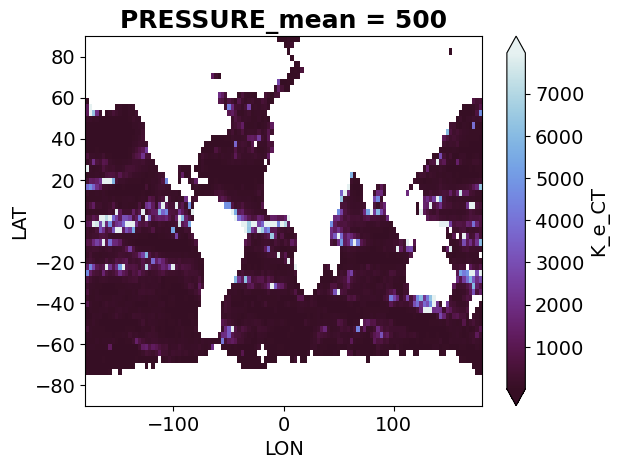

In [26]:
ds_pbar_grid.K_e_CT.sel(PRESSURE_mean=500).plot(y='LAT',x='LON',cmap=cmo.dense_r, robust=True)

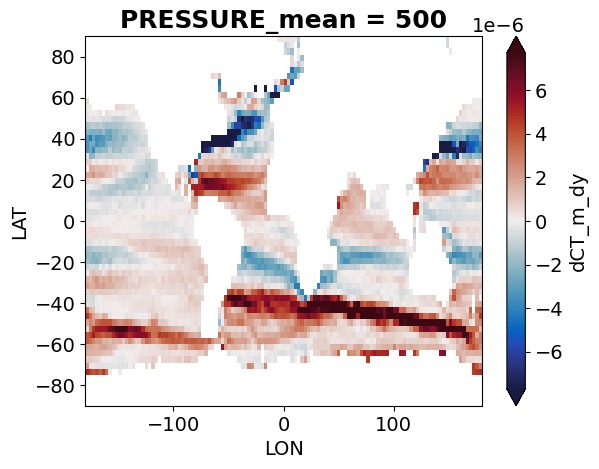

In [24]:
ds_pbar_grid.dCT_m_dy.sel(PRESSURE_mean=500).plot(y='LAT',x='LON',cmap=cmo.balance, robust=True)

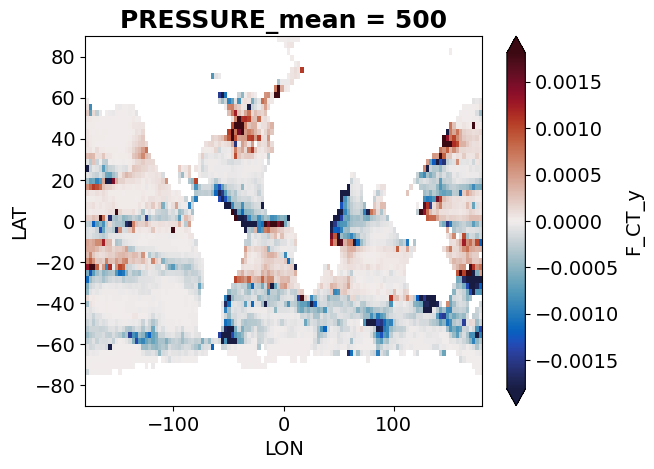

In [27]:
ds_pbar_grid.F_CT_y.sel(PRESSURE_mean=500).plot(y='LAT',x='LON',cmap=cmo.balance, robust=True)

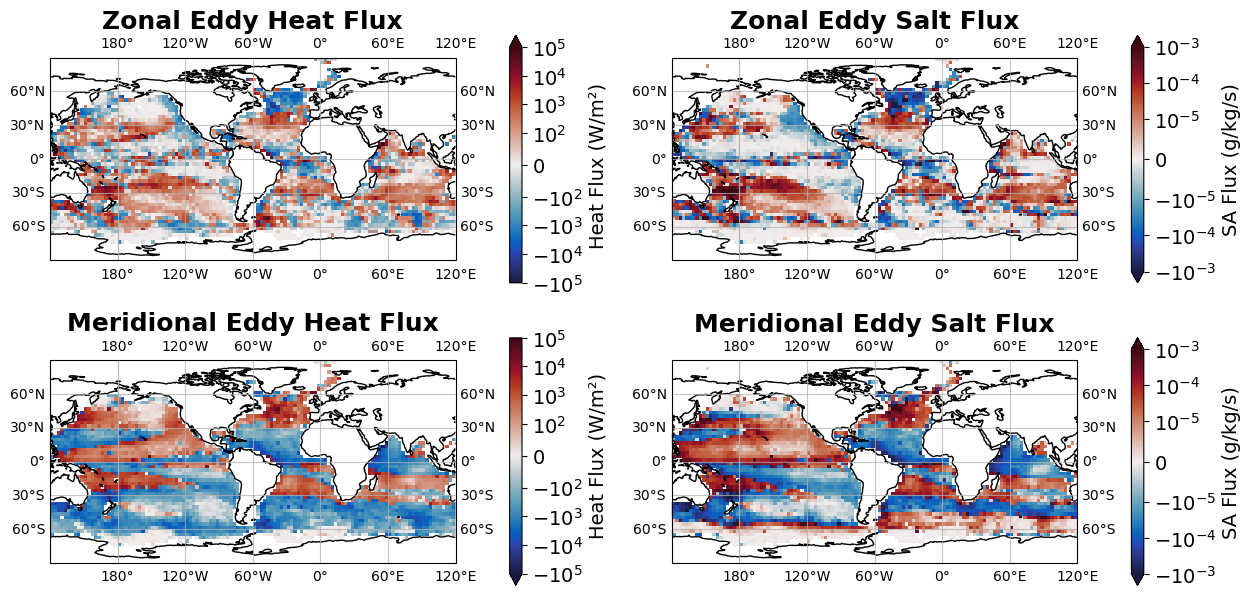

In [31]:
from matplotlib.colors import SymLogNorm

depth = 500
shrink, pad = 0.9, 0.1

# --- Configuration for each subplot ---
fields = [
    ("F_heat_x", cmo.balance, (1e2, 1e5), "symlog", "Heat Flux (W/m²)", "Zonal Eddy Heat Flux"),
    ("F_SA_x",   cmo.balance, (1e-5, 1e-3), "symlog", "SA Flux (g/kg/s)", "Zonal Eddy Salt Flux"),
    ("F_heat_y", cmo.balance, (1e2, 1e5), "symlog", "Heat Flux (W/m²)", "Meridional Eddy Heat Flux"),
    ("F_SA_y",   cmo.balance, (1e-5, 1e-3), "symlog", "SA Flux (g/kg/s)", "Meridional Eddy Salt Flux"),]


# --- Helper function to plot each panel ---
def plot_panel(ax, varname, cmap, vlims, norm_type, cbar_label, title):
    da = ds_pbar_grid[varname].sel(PRESSURE_mean=depth, method='nearest')

    # Choose normalization
    if norm_type == "symlog":
        linthresh = vlims[0]  # linear region around zero
        vmax = vlims[1]
        norm = SymLogNorm(
            linthresh=linthresh,
            vmin=-vmax,
            vmax=vmax
        )
    else:
        norm = colors.Normalize(vmin=vlims[0], vmax=vlims[1])

    # --- Base map ---
    da.plot(
        x='LON', y='LAT',
        cmap=cmap,
        norm=norm,
        transform=ccrs.PlateCarree(),
        ax=ax,
        cbar_kwargs={'shrink': shrink, 'pad': pad, 'label': cbar_label}
    )

    # --- Decorations ---
    ax.coastlines()
    ax.gridlines(draw_labels=True, alpha=0.75)
    ax.set_title(title)


# --- Create figure and loop ---
fig, axes = plt.subplots(
    2, 2, figsize=(15, 7.5),
    subplot_kw={'projection': ccrs.PlateCarree(central_longitude=-60)}
)
axes = axes.ravel()

for i, ax in enumerate(axes[:len(fields)]):
    var, cmap, vlims, norm_type, cbar_label, title = fields[i]
    plot_panel(ax, var, cmap, vlims, norm_type, cbar_label, title)

# Hide the extra subplot
for ax in axes[len(fields):]:
    ax.set_visible(False)

plt.subplots_adjust(wspace=0.15, hspace=0.1)
#plt.savefig(f"quals_paper/results/7_{ds_pbar_grid.sel(PRESSURE_mean=depth, method='nearest').PRESSURE_mean.data}.png")
#print(f"lon: {ds_pbar_grid.sel(PRESSURE_mean=depth, method='nearest').PRESSURE_mean.data}")